In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, mean, when, isnull


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

spark = SparkSession.builder \
                    .appName("Tutorial_DF") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


Mounted at /content/drive


In [4]:
file_path = "/content/Airline_Delay_Cause.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

In [13]:
from pyspark.sql.functions import col, isnan, when, count, avg, isnull, sum as spark_sum
from pyspark.sql.types import StringType, DoubleType, IntegerType, FloatType


numeric_types = (DoubleType, IntegerType, FloatType)
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, numeric_types)]
string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]


null_checks = [count(when(isnull(c), c)).alias(c) for c in string_cols] + \
              [count(when(isnull(c) | isnan(c), c)).alias(c) for c in numeric_cols]

df.select(null_checks).show()


df_cleaned = df.na.drop(subset=["arr_flights", "arr_del15", "year", "month"])
df_cleaned = df_cleaned.na.fill(0)

print(f"Total records after cleaning: {df_cleaned.count()}")

+-------+------------+-------+------------+----+-----+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|carrier|carrier_name|airport|airport_name|year|month|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+-------+------------+-------+------------+----+-----+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|      0|           0|      0|           0|   0|    0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+-------+-----------

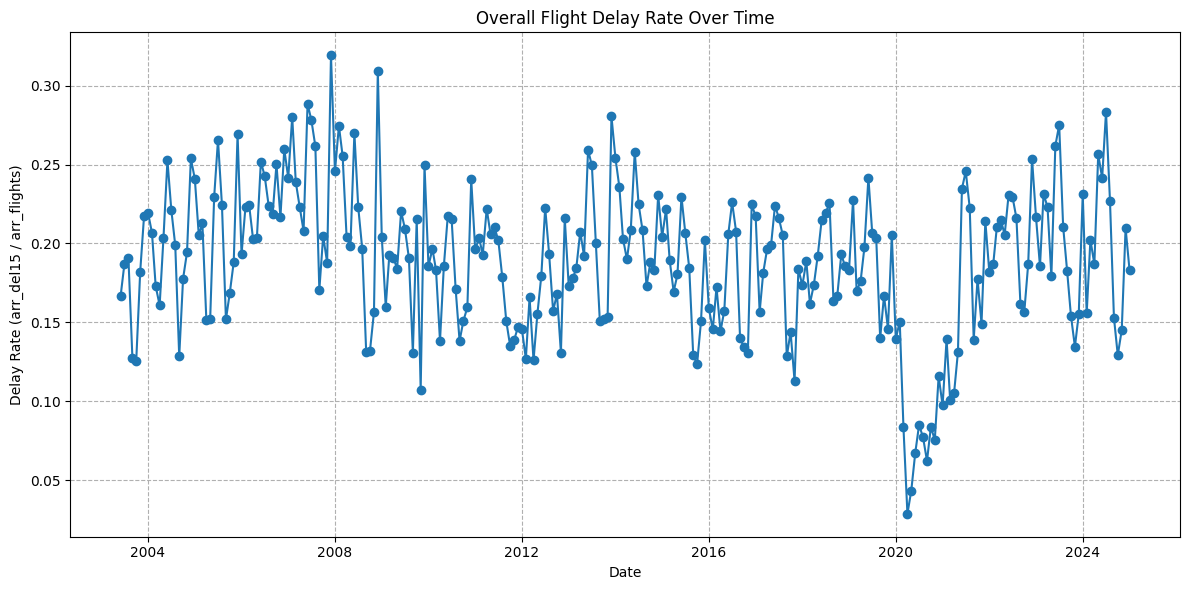

In [14]:
import matplotlib.pyplot as plt
import pandas as pd


time_series_agg = df_cleaned.groupBy("year", "month") \
    .agg((spark_sum("arr_del15") / spark_sum("arr_flights")).alias("delay_rate")) \
    .orderBy("year", "month")

pdf_time = time_series_agg.toPandas()
pdf_time['date'] = pd.to_datetime(pdf_time[['year', 'month']].assign(day=1))

plt.figure(figsize=(12, 6))
plt.plot(pdf_time['date'], pdf_time['delay_rate'], marker='o', color='tab:blue')
plt.title('Overall Flight Delay Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Delay Rate (arr_del15 / arr_flights)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

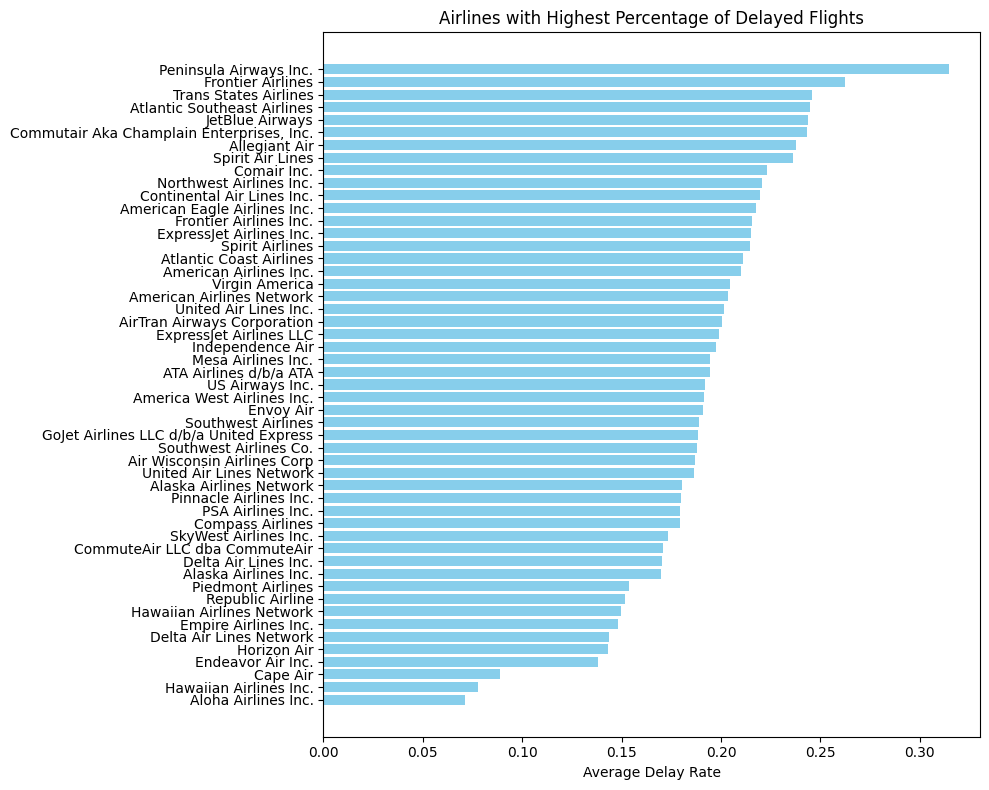

In [15]:

carrier_delay_agg = df_cleaned.groupBy("carrier_name") \
    .agg((spark_sum("arr_del15") / spark_sum("arr_flights")).alias("avg_delay_rate")) \
    .orderBy(col("avg_delay_rate").desc())

pdf_carrier = carrier_delay_agg.toPandas()

plt.figure(figsize=(10, 8))
plt.barh(pdf_carrier['carrier_name'], pdf_carrier['avg_delay_rate'], color='skyblue')
plt.xlabel('Average Delay Rate')
plt.title('Airlines with Highest Percentage of Delayed Flights')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

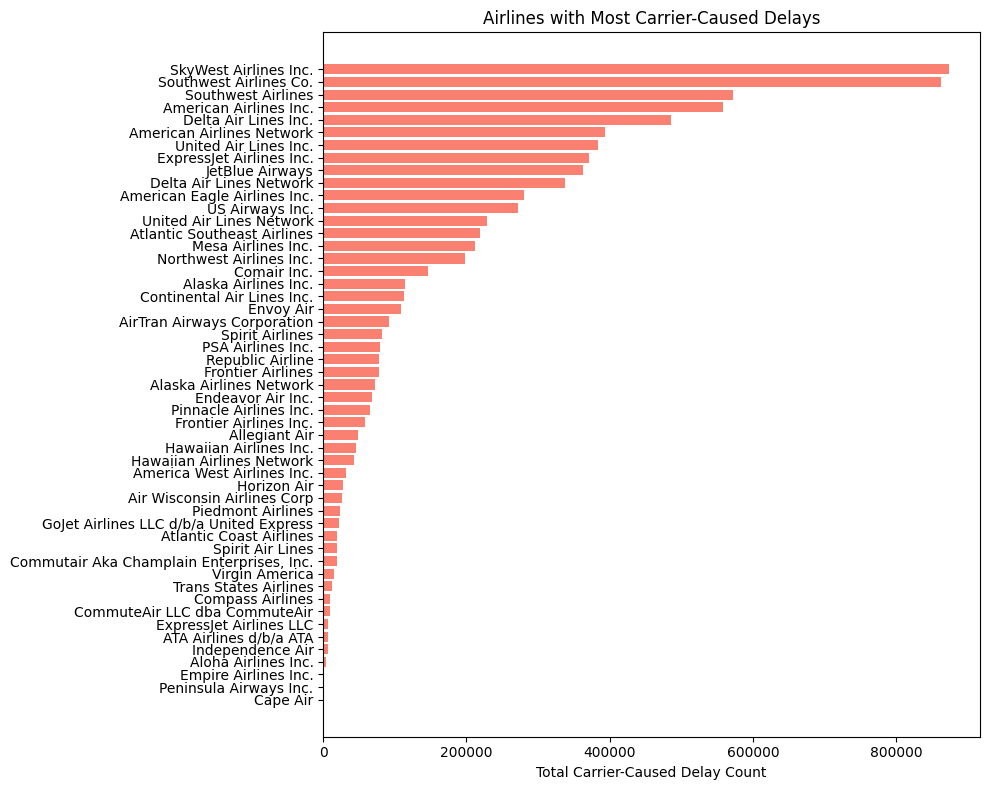

In [16]:

carrier_cause_agg = df_cleaned.groupBy("carrier_name") \
    .agg(spark_sum("carrier_ct").alias("total_carrier_delays")) \
    .orderBy(col("total_carrier_delays").desc())

pdf_carrier_cause = carrier_cause_agg.toPandas()

plt.figure(figsize=(10, 8))
plt.barh(pdf_carrier_cause['carrier_name'], pdf_carrier_cause['total_carrier_delays'], color='salmon')
plt.xlabel('Total Carrier-Caused Delay Count')
plt.title('Airlines with Most Carrier-Caused Delays')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

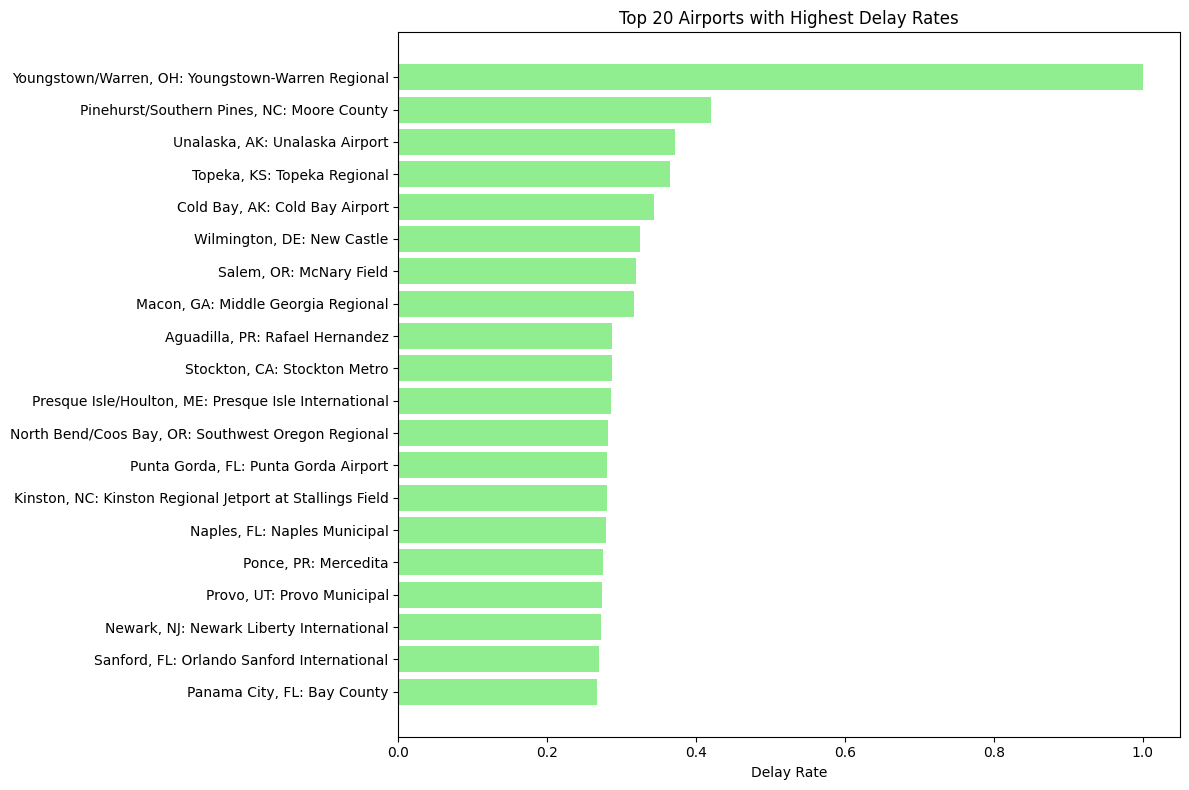

In [17]:

airport_delay_agg = df_cleaned.groupBy("airport_name") \
    .agg((spark_sum("arr_del15") / spark_sum("arr_flights")).alias("delay_rate")) \
    .orderBy(col("delay_rate").desc()) \
    .limit(20)


pdf_airport = airport_delay_agg.toPandas()


plt.figure(figsize=(12, 8))
plt.barh(pdf_airport['airport_name'], pdf_airport['delay_rate'], color='lightgreen')
plt.xlabel('Delay Rate')
plt.title('Top 20 Airports with Highest Delay Rates')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

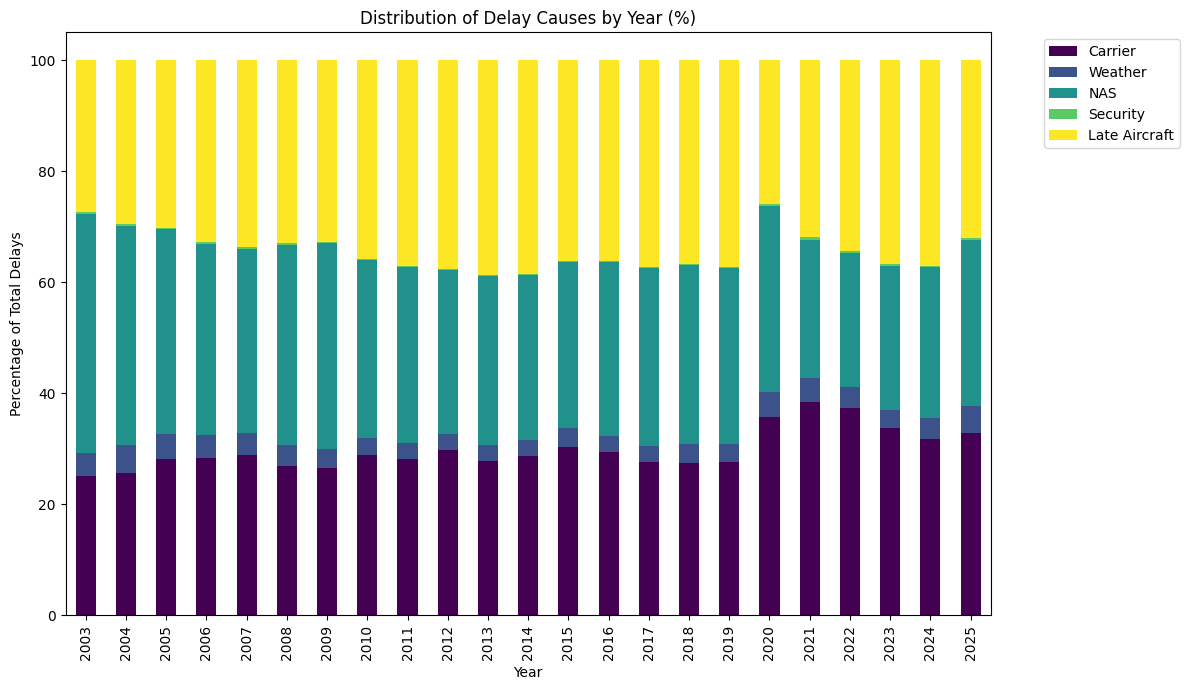

In [18]:

causes_agg = df_cleaned.groupBy("year") \
    .agg(
        spark_sum("carrier_ct").alias("Carrier"),
        spark_sum("weather_ct").alias("Weather"),
        spark_sum("nas_ct").alias("NAS"),
        spark_sum("security_ct").alias("Security"),
        spark_sum("late_aircraft_ct").alias("Late Aircraft")
    ).orderBy("year")


pdf_causes = causes_agg.toPandas().set_index('year')


pdf_causes_pct = pdf_causes.div(pdf_causes.sum(axis=1), axis=0) * 100


pdf_causes_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Distribution of Delay Causes by Year (%)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Delays')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

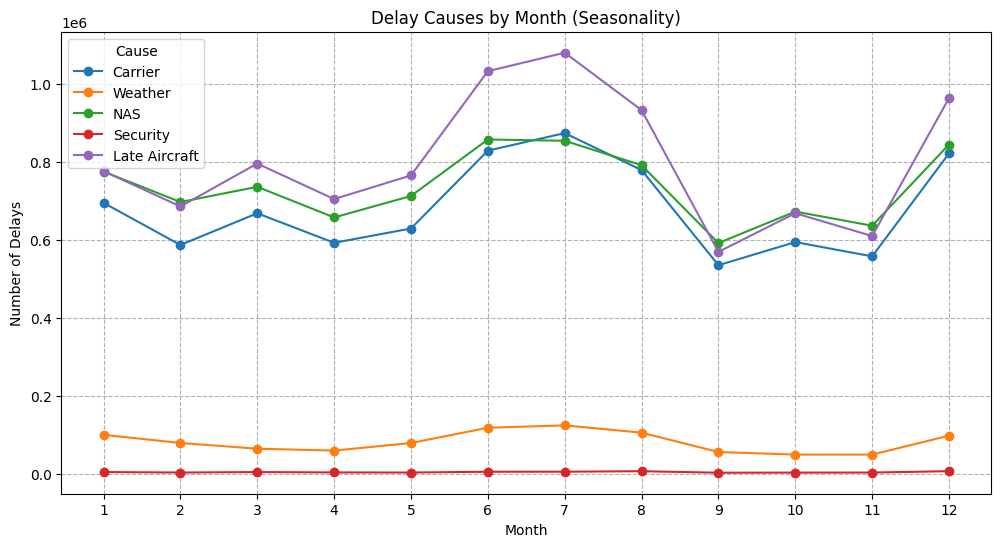

In [19]:

seasonal_causes = df_cleaned.groupBy("month") \
    .agg(
        spark_sum("carrier_ct").alias("Carrier"),
        spark_sum("weather_ct").alias("Weather"),
        spark_sum("nas_ct").alias("NAS"),
        spark_sum("security_ct").alias("Security"),
        spark_sum("late_aircraft_ct").alias("Late Aircraft")
    ).orderBy("month")


pdf_seasonal = seasonal_causes.toPandas().set_index('month')


pdf_seasonal.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Delay Causes by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Number of Delays')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--')
plt.legend(title='Cause')
plt.show()

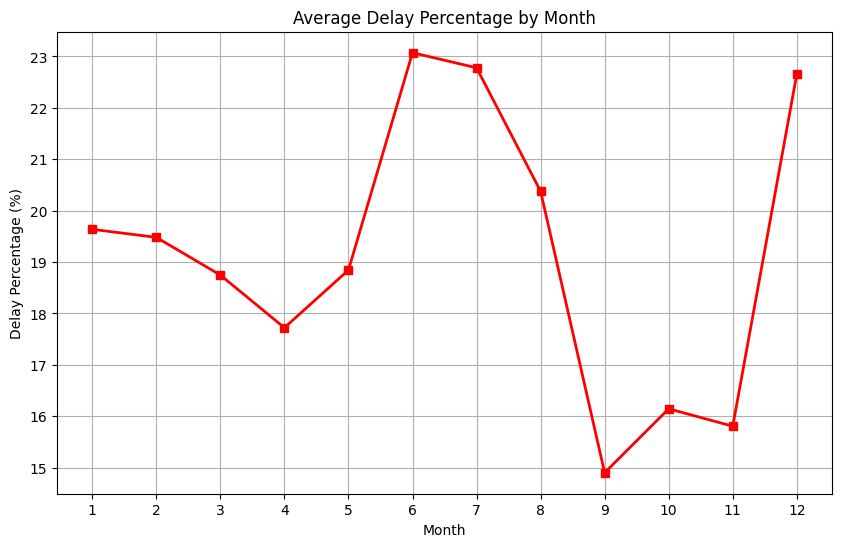

In [20]:

monthly_peak_agg = df_cleaned.groupBy("month") \
    .agg((spark_sum("arr_del15") / spark_sum("arr_flights") * 100).alias("delay_pct")) \
    .orderBy("month")

pdf_monthly_peak = monthly_peak_agg.toPandas()


plt.figure(figsize=(10, 6))
plt.plot(pdf_monthly_peak['month'], pdf_monthly_peak['delay_pct'], color='red', marker='s', linewidth=2)
plt.title('Average Delay Percentage by Month')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()